In [155]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [156]:
churn_raw = pd.read_csv('Churn_Modelling.csv')

churn_raw.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [157]:
churn_raw.shape

(10000, 14)

In [158]:
churn = churn_raw.copy()
churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [159]:
churn = churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [160]:
churn[(churn['Gender'] != "Female") & (churn['Gender'] != "Male")]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [161]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [162]:
churn.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [163]:
churn['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Text(0.5, 1.0, 'Churn rate')

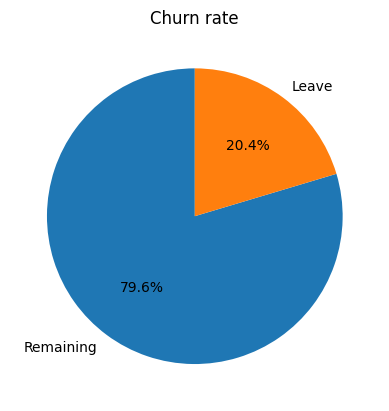

In [164]:
Exit_cnt = churn['Exited'].value_counts()
plt.pie(Exit_cnt, labels=['Remaining', 'Leave'], autopct='%1.1f%%', startangle=90)
plt.title("Churn rate")

Text(0.5, 1.0, 'Churn rate by Age')

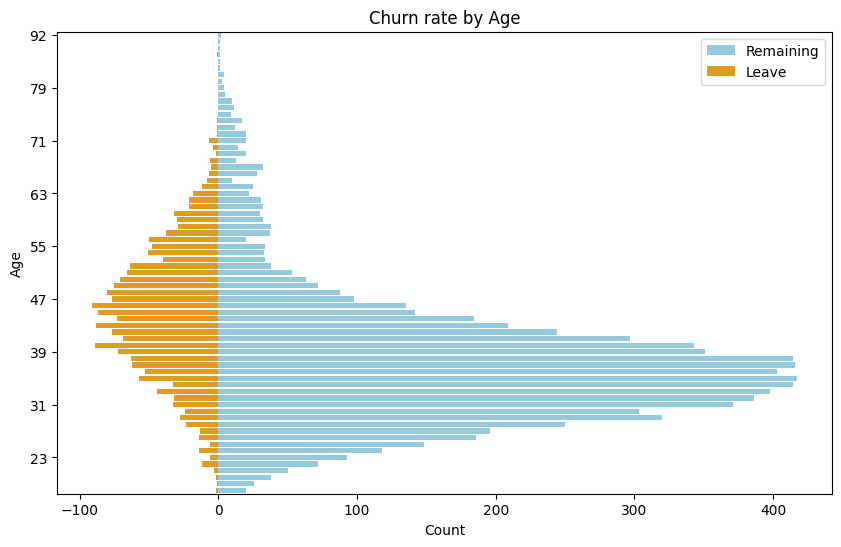

In [165]:
churn_age = churn.groupby('Age')['Exited'].value_counts().unstack(fill_value=0)
churn_age = churn_age.reset_index()
churn_age.columns = ['Age', 'Remaining', 'Leave']
churn_age = churn_age.sort_values(by='Age', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=churn_age, x="Remaining", y="Age", color='skyblue', label='Remaining', orient='h', order=churn_age['Age'])
sns.barplot(data=churn_age, x=-churn_age['Leave'], y="Age", color='orange', label='Leave', orient='h' , order=churn_age['Age'])

ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xlabel("Count")
plt.title("Churn rate by Age")

Text(0.5, 1.0, 'Churn rate by CreditScore')

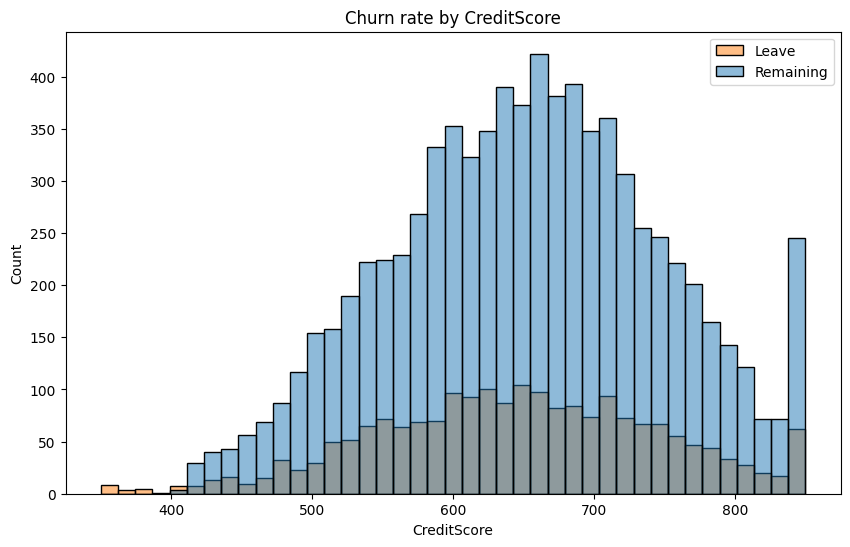

In [166]:
plt.figure(figsize=(10, 6))
sns.histplot(x='CreditScore', hue='Exited', multiple='layer', data=churn)
plt.legend(labels=['Leave', 'Remaining'])
plt.title("Churn rate by CreditScore")

Text(0.5, 1.0, 'Churn rate by Geography')

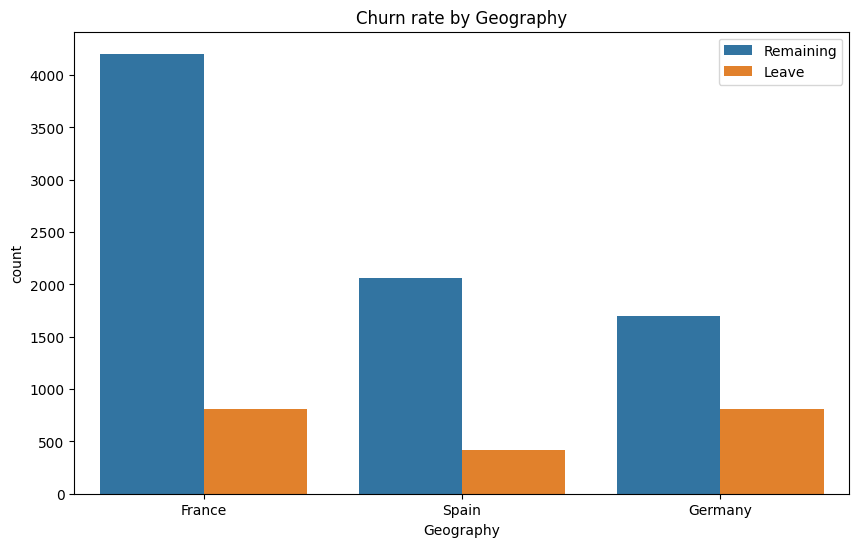

In [167]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn, x='Geography', hue='Exited')
plt.legend(labels=['Remaining', 'Leave'])
plt.title("Churn rate by Geography")

Text(0.5, 1.0, 'Churn rate by Gender')

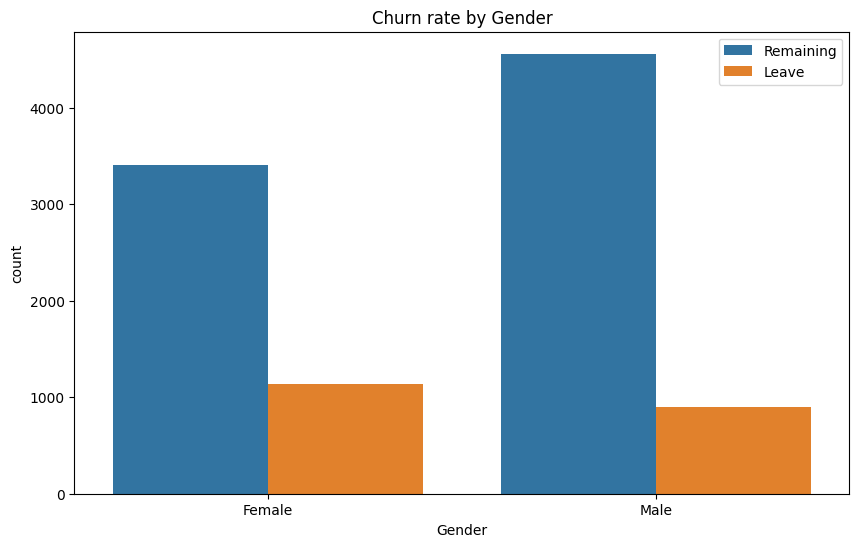

In [168]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn, x='Gender', hue='Exited')
plt.legend(labels=['Remaining', 'Leave'])
plt.title("Churn rate by Gender")

Text(0.5, 1.0, 'Churn rate by Balance')

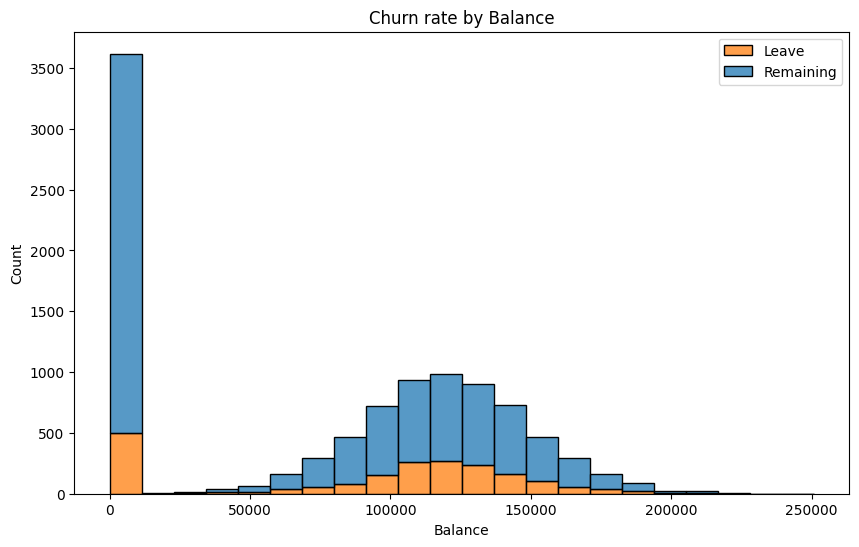

In [169]:
plt.figure(figsize=(10, 6))
sns.histplot(data=churn, x='Balance', hue='Exited', multiple='stack')
plt.legend(labels=['Leave', 'Remaining'])
plt.title("Churn rate by Balance")

Text(0.5, 1.0, 'Churn rate by Number of Products')

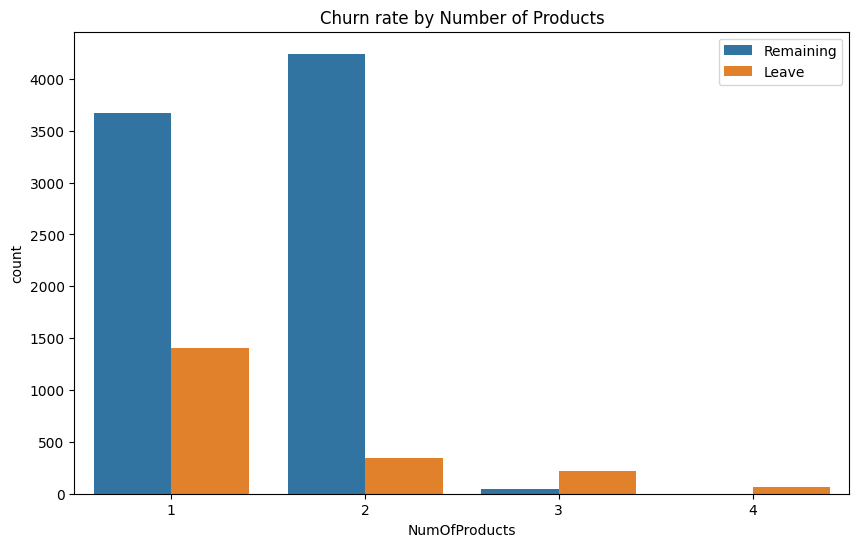

In [170]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn, x='NumOfProducts', hue='Exited')
plt.legend(labels=['Remaining', 'Leave'])
plt.title("Churn rate by Number of Products")

Text(0.5, 1.0, 'Churn rate by have a Credit Card')

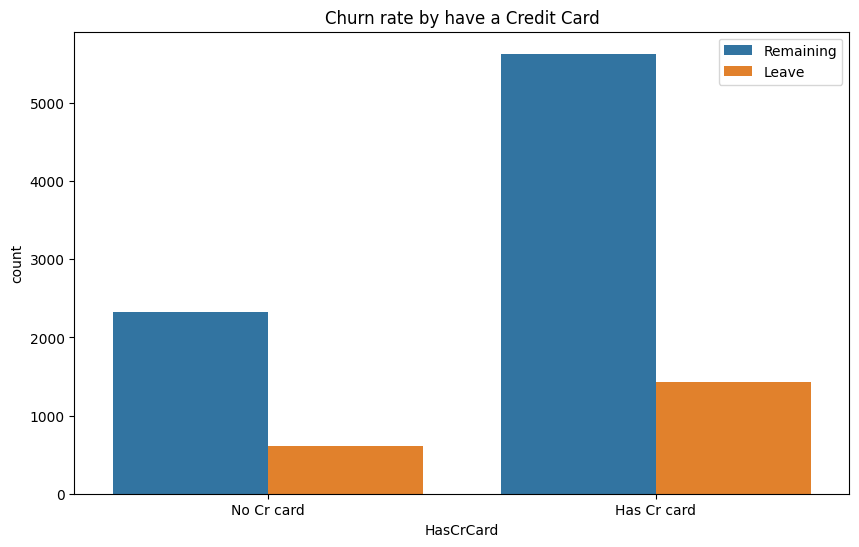

In [171]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn, x='HasCrCard', hue='Exited')
plt.legend(labels=['Remaining', 'Leave'])
plt.xticks([0,1], ['No Cr card', 'Has Cr card'])
plt.title("Churn rate by have a Credit Card")

Text(0.5, 1.0, 'Churn rate by Active Customers')

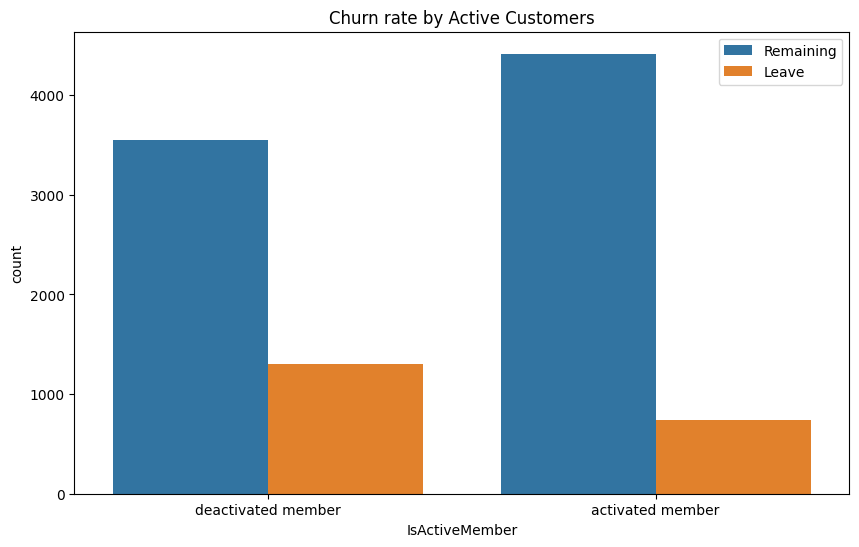

In [172]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn, x='IsActiveMember', hue='Exited')
plt.legend(['Remaining', 'Leave'])
plt.xticks([0,1], ['deactivated member', 'activated member'])
plt.title("Churn rate by Active Customers")

C:\Users\PC\AppData\Local\Temp\ipykernel_16996\3393604883.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_bin_counts = churn.groupby(['SalaryBin', 'Exited']).size().unstack(fill_value=0)


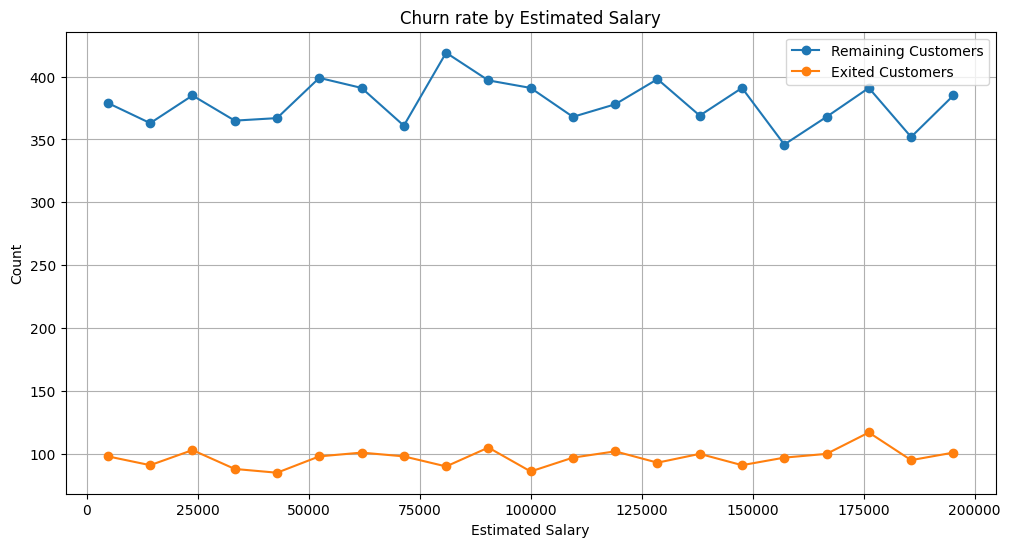

In [174]:
bins = np.linspace(churn['EstimatedSalary'].min(), churn['EstimatedSalary'].max(), 22)
churn['SalaryBin'] = pd.cut(churn['EstimatedSalary'], bins)

salary_bin_counts = churn.groupby(['SalaryBin', 'Exited']).size().unstack(fill_value=0)
salary_bin_counts.columns = ['Remaining', 'Exited']

salary_bin_counts['BinMid'] = [i.mid for i in salary_bin_counts.index]

plt.figure(figsize=(12, 6))
plt.plot(salary_bin_counts['BinMid'], salary_bin_counts['Remaining'], label='Remaining', marker='o')
plt.plot(salary_bin_counts['BinMid'], salary_bin_counts['Exited'], label='Exited', marker='o')
plt.xlabel("Estimated Salary")
plt.ylabel("Count")
plt.title("Churn rate by Estimated Salary")
plt.legend()
plt.grid(True)